<a href="https://colab.research.google.com/github/mf2056/F20AA_CW2/blob/main/Explore%20and%20Viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Exploration and Visualization

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets into variables
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# Verify they loaded correctly
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(train.head())

Train shape: (288000, 2)
Test shape: (89100, 2)
                                                text  rating
0  This place is TERRIBLE; the people in charge a...       2
1  Terrible Service! And they are saying that I n...       1
2  Absolutely terrible company.  They sent me to ...       1
3  To find it, either park in front of the Tuesda...       4
4  Mall location. Used their services for sedan. ...       4


In [5]:
# Basic Stats
print(f"Total Training Samples: {train.shape[0]}")
print(f"Missing Values:\n{train.isnull().sum()}")

# Calculate Review Lengths (Characters and Words)
train['char_count'] = train['text'].astype(str).apply(len)
train['word_count'] = train['text'].astype(str).apply(lambda x: len(x.split()))

Total Training Samples: 288000
Missing Values:
text      0
rating    0
dtype: int64


/tmp/ipykernel_148/1615834932.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='rating', data=train, palette='viridis')


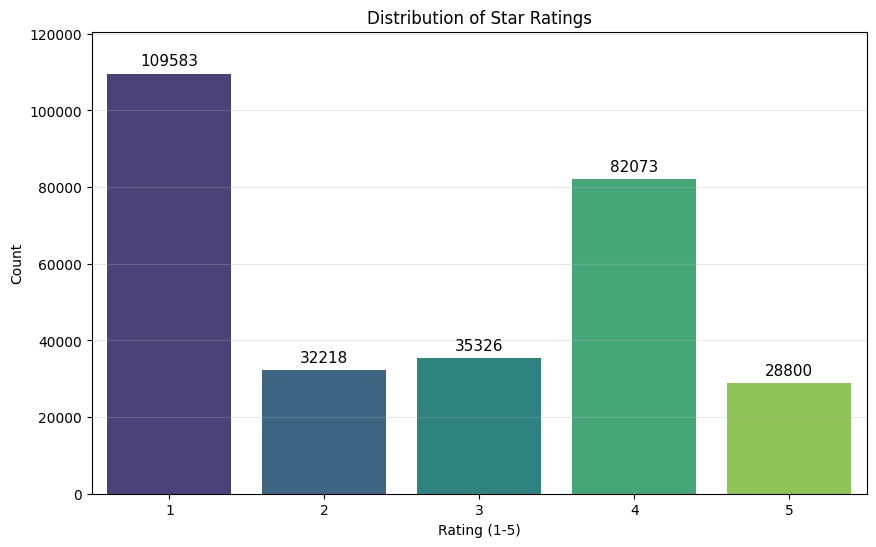

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='rating', data=train, palette='viridis')

# Add the count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11,)

plt.title('Distribution of Star Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# Adjust y-limit slightly to make room for the text
plt.ylim(0, train['rating'].value_counts().max() * 1.1)

plt.show()

/tmp/ipykernel_148/1156624025.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='rating', y='word_count', data=train,


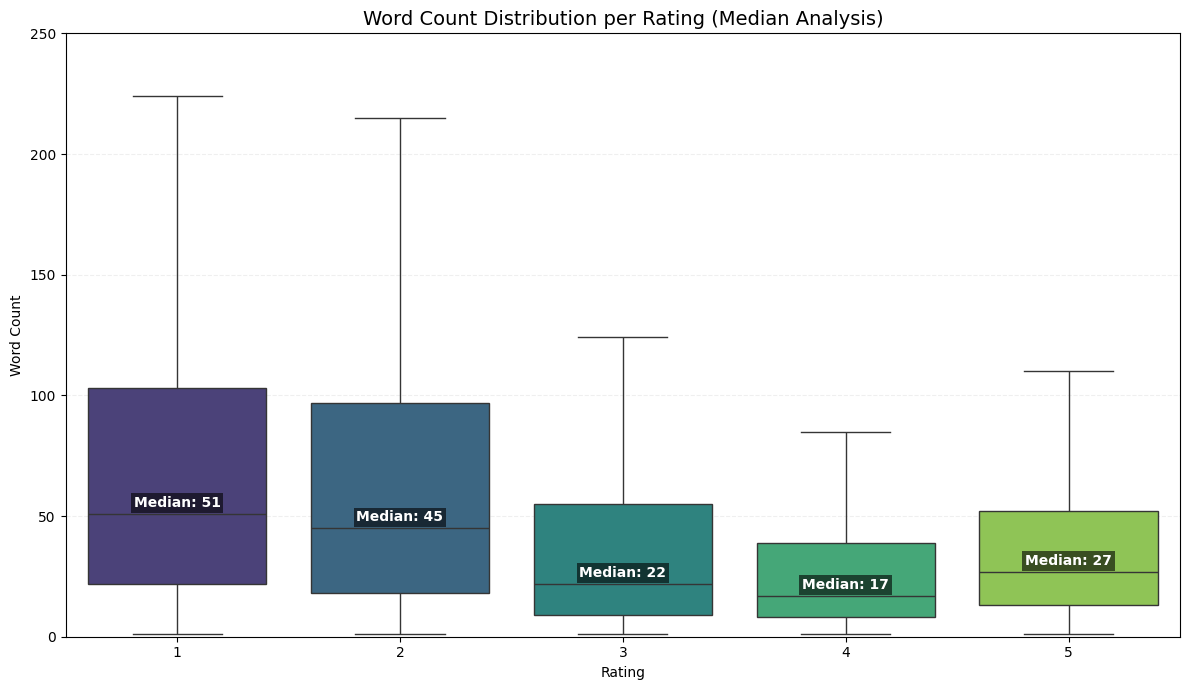

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# 1. Create the boxplot without outliers for a cleaner look
ax = sns.boxplot(x='rating', y='word_count', data=train,
                 showfliers=False, palette='viridis')

# 2. Calculate the medians to label them specifically
medians = train.groupby(['rating'])['word_count'].median().values

# 3. Add only the median value text
for i, median in enumerate(medians):
    ax.text(i, median + 1.5, f'Median: {int(median)}',
            ha='center', va='bottom', fontweight='bold', color='white',
            bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=2))

plt.title('Word Count Distribution per Rating (Median Analysis)', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.grid(axis='y', alpha=0.2, linestyle='--')

# Optional: Zoom in slightly to make the boxes larger if your data allows
plt.ylim(0, 250)

plt.tight_layout()
plt.show()

In [17]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Download the stopword list if you haven't already
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Add specific words you want to ignore that aren't in the standard list
# (Optional: "google", "place", "service", etc.)
stop_words.update(['this', 'that', 'they', 'have', 'had', 'are', 'was', 'were', 'be', 'been', 'being'])

def get_most_common(rating, num_words=20):
    # Filter for the rating and join text
    text_data = train[train['rating']==rating]['text'].str.lower()

    # Tokenize and filter in one go
    all_words = []
    for review in text_data:
        words = review.split()
        filtered = [w for w in words if w.isalpha() and w not in stop_words]
        all_words.extend(filtered)

    return Counter(all_words).most_common(num_words)

print("--- 1-Star Keywords ---")
print(get_most_common(1))

print("\n--- 5-Star Keywords ---")
print(get_most_common(5))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


--- 1-Star Keywords ---
[('get', 33549), ('would', 33488), ('never', 27878), ('told', 26905), ('one', 24821), ('time', 22941), ('even', 22542), ('said', 21797), ('back', 21796), ('go', 20422), ('like', 19455), ('called', 19223), ('place', 18769), ('service', 16902), ('call', 16832), ('could', 15254), ('people', 14968), ('got', 14672), ('went', 14530), ('customer', 14134)]

--- 5-Star Keywords ---
[('great', 9239), ('recommend', 4828), ('would', 3656), ('best', 3628), ('highly', 3594), ('always', 3580), ('service', 3438), ('staff', 3430), ('time', 3358), ('good', 3193), ('work', 3005), ('get', 2784), ('place', 2783), ('thank', 2718), ('friendly', 2687), ('love', 2495), ('professional', 2282), ('really', 2188), ('experience', 2069), ('like', 2022)]
